### Review about Multi-Layer Perceptron (MLP)
Reference: https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/


A Multi-Layer Perceptron (MLP) is a type of artificial neural network that consists of multiple layers of nodes, where each layer is fully connected to the next one. It is a feedforward neural network, meaning that information flows in one direction from the input layer to the output layer.
Using an MLP involves the following steps:
1. **Define the Architecture**: Decide on the number of layers and the number of neurons in each layer. The input layer should match the number of features in your dataset, and the output layer should match the number of classes (for classification) or the number of output values (for regression).
2. **Choose Activation Functions**: Select appropriate activation functions for the hidden layers (e.g., ReLU, sigmoid) and the output layer (e.g., softmax for classification, linear for regression).
3. **Initialize Weights**: Initialize the weights of the connections between neurons, typically using methods like Xavier or He initialization.
4. **Forward Propagation**: Pass the input data through the network to compute the output. This involves calculating the weighted sum of inputs for each neuron and applying the activation function.
5. **Compute Loss**: Calculate the loss using an appropriate loss function (e.g., cross-entropy for classification, mean squared error for regression).
6. **Backpropagation**: Compute the gradients of the loss with respect to the weights and update the weights using an optimization algorithm (e.g., stochastic gradient descent, Adam).
7. **Train the Model**: Repeat the forward propagation, loss computation, and backpropagation steps for multiple epochs until the model converges or reaches a satisfactory level of performance.
8. **Evaluate the Model**: Assess the performance of the trained MLP using metrics such as accuracy, precision, recall, F1-score for classification, or mean absolute error for regression.Here is a simple example of how to implement an MLP using Python and the Keras library

### Roles of MLP in Speech Recognition

1. **Feature Extraction**: MLPs can be used to extract relevant features from raw audio signals, such as Mel-frequency cepstral coefficients (MFCCs) or spectrograms   
2. **Classification**: MLPs can classify audio signals into different categories, such as speech vs. non-speech, or different spoken words or phrases.
3. **Noise Reduction**: MLPs can be trained to denoise audio signals, improving the quality of speech recognition in noisy environments.
4. **Speaker Identification**: MLPs can be used to identify individual speakers based on their unique vocal characteristics.
5. **Emotion Recognition**: MLPs can analyze speech signals to detect the emotional state of the speaker, which can be useful in applications like customer service or mental health monitoring.

Using the MINST dataset, which consists of handwritten digit images, we can create a simple MLP for classification

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"Training data shape: {x_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {x_test.shape}, Testing labels shape: {y_test.shape}")

Training data shape: (60000, 28, 28), Training labels shape: (60000,)
Testing data shape: (10000, 28, 28), Testing labels shape: (10000,)


Normalizing the pixel values of the images to be between 0 and 1 can help improve the performance of the MLP. This is typically done by dividing the pixel values by 255, as the original pixel values range from 0 to 255. Normalization helps the model converge faster during training and can lead to better performance.

In [11]:
gray_scale = 255

x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", x_test.shape)
print("Target matrix (y_test):", y_test.shape)

Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


Visualizing some of the images from the dataset can help us understand the data better. We can use libraries like Matplotlib to display a few sample images along with their corresponding labels.

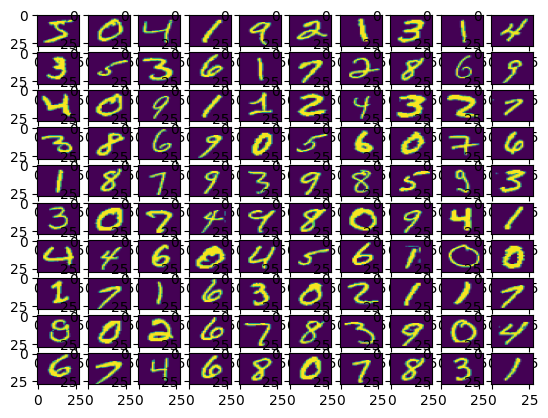

In [12]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto')
        k += 1
plt.show()

Here we build a Sequential neural network model. The model consists of:
- A Flatten layer to convert the 2D image data into a 1D vector.
- A Dense layer with 128 neurons and ReLU activation function, which serves as a hidden layer.
- An output Dense layer with 10 neurons (one for each digit class) and a softmax activation function, which outputs the probabilities for each class.


In [13]:
model = Sequential([Flatten(input_shape=(28, 28)),
    Dense(256, activation='sigmoid'),  
    Dense(128, activation='sigmoid'), 
    Dense(10, activation='softmax')])

Once the model is defined we compile it by specifying:
- The optimizer (e.g., 'adam') which determines how the model will be updated based on the loss function.
- The loss function (e.g., 'sparse_categorical_crossentropy') which measures how well the model's predictions match the true labels.
- The metrics (e.g., 'accuracy') which we want to track during training and evaluation.

In [14]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Training the Model with epochs and batch size

In [15]:
mod = model.fit(x_train, y_train, epochs=10, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4231 - loss: 2.1075 - val_accuracy: 0.6737 - val_loss: 1.7655
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6880 - loss: 1.4384 - val_accuracy: 0.7659 - val_loss: 1.0949
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7956 - loss: 0.9242 - val_accuracy: 0.8473 - val_loss: 0.7331
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8565 - loss: 0.6582 - val_accuracy: 0.8842 - val_loss: 0.5420
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8828 - loss: 0.5097 - val_accuracy: 0.8994 - val_loss: 0.4336
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8964 - loss: 0.4236 - val_accuracy: 0.9077 - val_loss: 0.3715
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9038 - loss: 0.3712 - val_accuracy: 0.9134 - val_loss: 0.3326
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9103 - loss: 0.3361 - val_accuracy: 0.9193 - val_l

Evaluating the Model on the test set to see how well it performs on unseen data. Using Test loss and Test accuracy as metrics to assess the model's performance.

In [16]:
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.2734682261943817, 0.9254000186920166]


Vissualizing the training history can help us understand how the model's performance evolved over time. We can plot the training and validation loss and accuracy to see if the model is overfitting or underfitting.

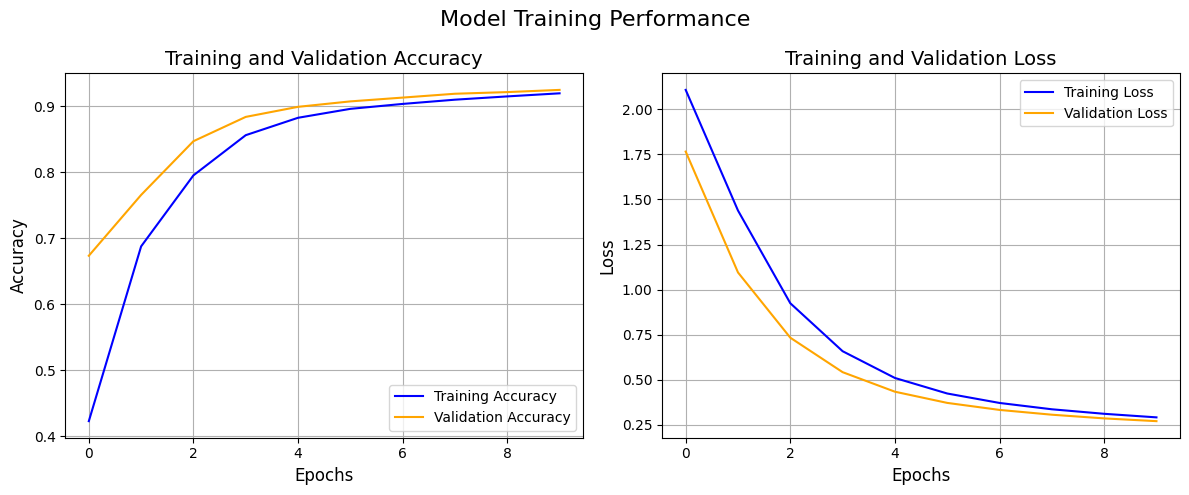

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()

Some sample predictions from the test set can be visualized to see how well the model is performing on individual examples. We can display the images along with their predicted and true labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


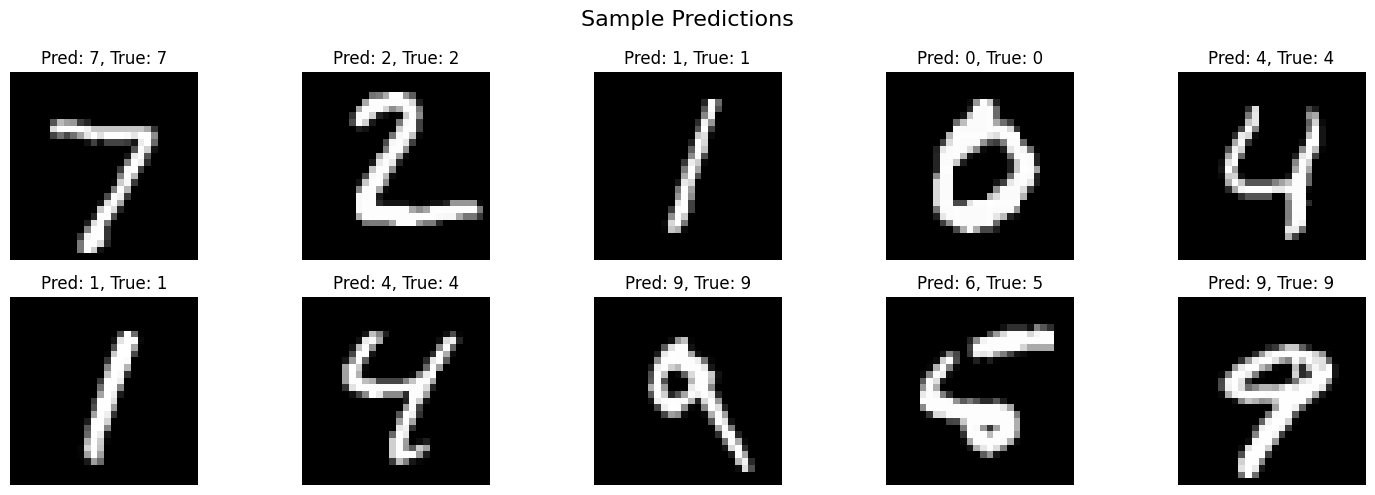

In [19]:
def plot_predictions(model, x_test, y_test, num_samples=10):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(2, num_samples//2, i+1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        pred = np.argmax(model.predict(x_test[i:i+1]))
        true_label = y_test[i]
        plt.title(f"Pred: {pred}, True: {true_label}")
        plt.axis('off')
    plt.suptitle("Sample Predictions", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_predictions(model, x_test, y_test)

In summary, using an MLP involves defining the architecture, choosing activation functions, initializing weights, performing forward propagation, computing loss, backpropagation, training the model, and evaluating its performance.
